In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pertpy as pt

In [2]:
adata = sc.read("../results/adata/09-annotation.h5ad")

In [3]:
# Count cells per sample and cluster
counts = (
    adata.obs
    .groupby(["sample", "leiden_0.5"])
    .size()
    .reset_index(name="n_cells")
)

# Total cells per sample
totals = (
    adata.obs
    .groupby("sample")
    .size()
    .reset_index(name="total_cells")
)

# Merge and compute proportions
df = counts.merge(totals, on="sample")
df["proportion"] = df["n_cells"] / df["total_cells"]

# Add day information (one value per sample)
sample_info = (
    adata.obs[["sample", "day"]]
    .drop_duplicates()
)

df = df.merge(sample_info, on="sample")

/tmp/ipykernel_3956265/491960423.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["sample", "leiden_0.5"])
/tmp/ipykernel_3956265/491960423.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("sample")


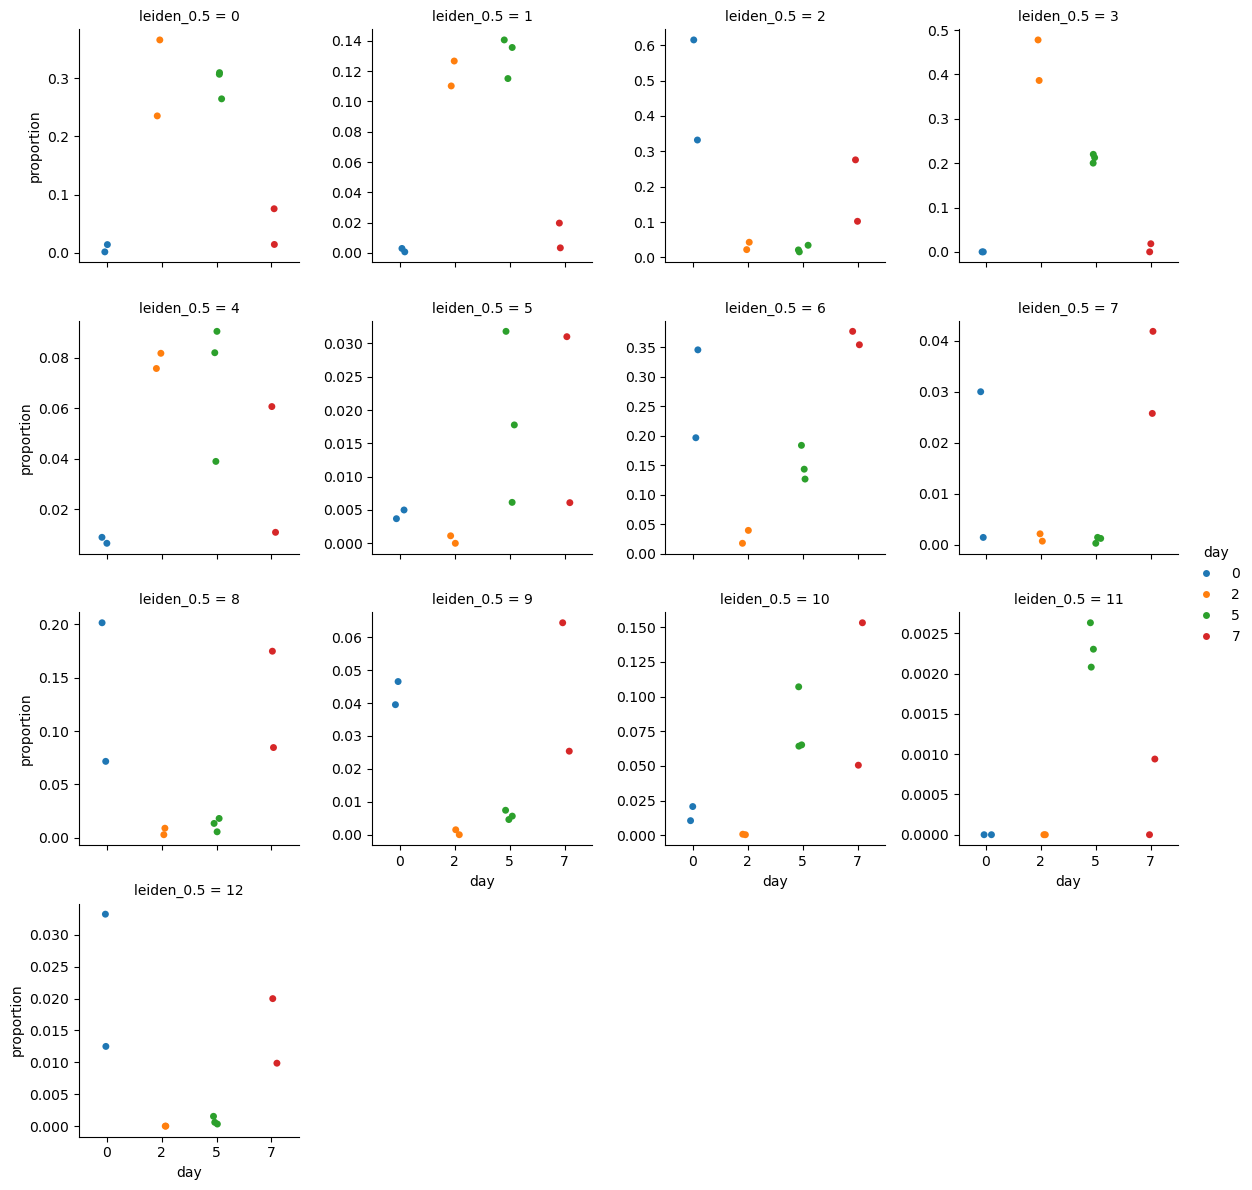

In [4]:
g = sns.catplot(
    data=df,
    x="day",
    y="proportion",
    col="leiden_0.5",
    # kind="box",
    hue="day",
    col_wrap=4,
    sharey=False,
    height=3
)

plt.show()

In [6]:
sccoda_model = pt.tl.Sccoda()
sccoda_data = sccoda_model.load(
    adata,
    type="cell_level",
    generate_sample_level=True,
    cell_type_identifier="leiden_0.5",
    sample_identifier="sample",
    covariate_obs=["day"],
)


MuData object with n_obs × n_vars = 22792 × 31669
  2 modalities
    rna:	22783 × 31656
      obs:	'sample', 'day', 'scdblfinder_score', 'scdblfinder_class', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'malat1_expression', 'intronic_fraction', 'n_genes', 'log1p_total_counts_outlier', 'log1p_n_genes_by_counts_outlier', 'pct_counts_in_top_20_genes_outlier', 'pct_counts_mt_outlier', 'malat1_expression_outlier', 'intronic_fraction_outlier', 'pct_counts_hb_outlier', 'leiden_0.15', 'leiden_0.5', 'cell_type', 'scCODA_sample_id'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means

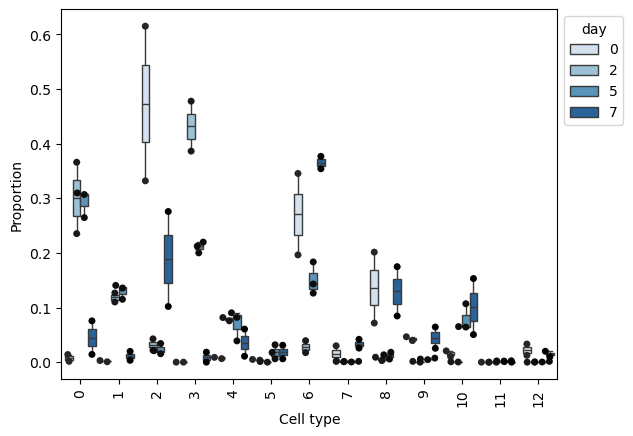

In [7]:
sccoda_model.plot_boxplots(sccoda_data, feature_name="day", add_dots=True)
plt.show()

In [8]:
sccoda_data = sccoda_model.prepare(
    sccoda_data,
    formula="day",
)

In [9]:
sccoda_model.run_nuts(sccoda_data)

sample: 100%|██████████| 11000/11000 [03:11<00:00, 57.36it/s, 511 steps of size 7.38e-03. acc. prob=0.80]


In [10]:
sccoda_model.summary(sccoda_data)

                                          Compositional Analysis summary                                           
┌─────────────────────────────────────────────┬───────────────────────────────────────────────────────────────────┐
│ Name                                        │ Value                                                             │
├─────────────────────────────────────────────┼───────────────────────────────────────────────────────────────────┤
│ Data                                        │ Data: 9 samples, 13 cell types                                    │
│ Reference cell type                         │ 7                                                                 │
│ Formula                                     │ day                                                               │
└─────────────────────────────────────────────┴───────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│             Final Parameter  Expected Sample                                                                    │
│ leiden_0.5                                                                                                      │
│ 0               -0.277           66.359                                                                         │
│ 1               -0.814           38.787                                                                         │
│ 2                2.299          872.248                                                                         │
│ 3               -1.276           24.436                                                                         │
│ 4               -0.275           66.491                                                                         │
│ 5               -0.571           49.456                                                                         │
│ 6                2.185          778.270                                                                         │
│ 7               -0.354           61.441                                                                         │
│ 8                1.170          282.047                                                                         │
│ 9                0.340          122.986                                                                         │
│ 10               0.050           92.026                                                                         │
│ 11              -1.308           23.667                                                                         │
│ 12              -0.485           53.897                                                                         │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                      Final Parameter  Expected Sample  log2-fold change                                         │
│ Covariate Cell Type                                                                                             │
│ dayT.2    0               4.814           735.599            3.471                                              │
│           1               4.444           296.984            2.937                                              │
│           2               0.000            78.491           -3.474                                              │
│           3               6.207          1091.256            5.481                                              │
│           4               3.500           198.060            1.575                                              │
│           5               0.000             4.450           -3.474                                              │
│           6               0.000            70.034           -3.474                                              │
│           7               0.000             5.529           -3.474                                              │
│           8               0.000            25.380           -3.474                                              │
│           9               0.000            11.067           -3.474                                              │
│           10              0.000             8.281           -3.474                                              │
│           11              0.000             2.130           -3.474                                              │
│           12              0.000             4.850           -3.474                                              │
│ dayT.5    0               4.528           730.944            3.461                                              │
│           1               4.252           324.186            3.063                                              │
│           2               0.000           103.747           -3.072                                              │
│           3               5.195           524.280            4.423                                              │
│           4               3.044           165.940            1.319                                              │
│           5               1.940            40.946           -0.272                                              │
│           6               1.425           384.799           -1.016                                              │
│           7               0.000             7.308           -3.072                                              │
│           8               0.000            33.547           -3.072                                              │
│           9               0.000            14.628           -3.072                                              │
│           10              2.867           192.560            1.065                                              │
│           11              0.000             2.815           -3.072                                              │
│           12              0.000             6.411           -3.072                                              │
│ dayT.7    0               0.000            79.037            0.252                                              │
│           1               0.000            46.197            0.252                                              │
│           2              -0.627           555.109           -0.652                                              │
│           3               0.000            29.105     

In [11]:
sccoda_model.credible_effects(sccoda_data)

Covariate  Cell Type
day[T.2]   0             True
           1             True
           2            False
           3             True
           4             True
           5            False
           6            False
           7            False
           8            False
           9            False
           10           False
           11           False
           12           False
day[T.5]   0             True
           1             True
           2            False
           3             True
           4             True
           5             True
           6             True
           7            False
           8            False
           9            False
           10            True
           11           False
           12           False
day[T.7]   0            False
           1            False
           2             True
           3            False
           4            False
           5            False
           6       

/home/FCAM/kcobb/.miniforge/envs/single-cell/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/FCAM/kcobb/.miniforge/envs/single-cell/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/FCAM/kcobb/.miniforge/envs/single-cell/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


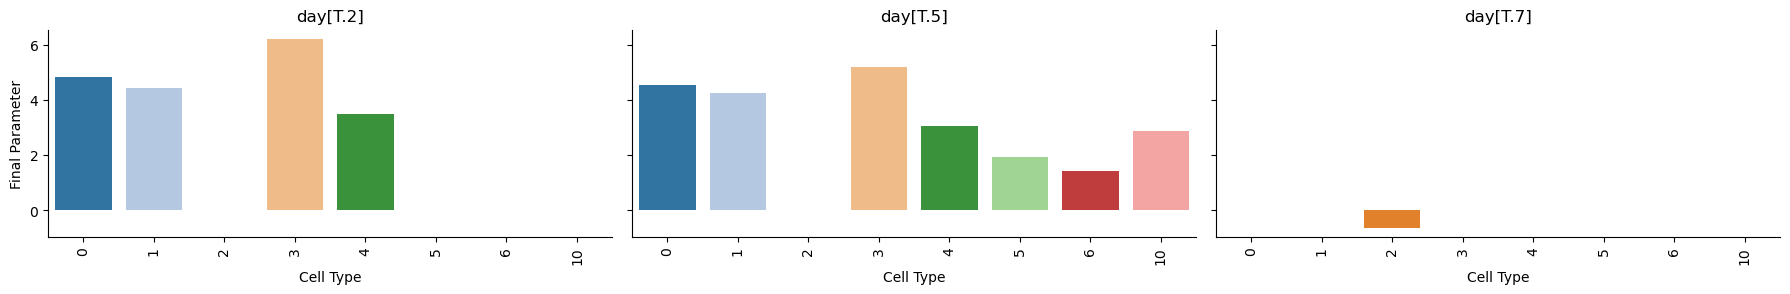

In [12]:
sccoda_model.plot_effects_barplot(sccoda_data, parameter="Final Parameter")

In [13]:
sccoda_model.set_fdr(sccoda_data, est_fdr=0.5)
sccoda_model.summary(sccoda_data)

                                          Compositional Analysis summary                                           
┌─────────────────────────────────────────────┬───────────────────────────────────────────────────────────────────┐
│ Name                                        │ Value                                                             │
├─────────────────────────────────────────────┼───────────────────────────────────────────────────────────────────┤
│ Data                                        │ Data: 9 samples, 13 cell types                                    │
│ Reference cell type                         │ 7                                                                 │
│ Formula                                     │ day                                                               │
└─────────────────────────────────────────────┴───────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│             Final Parameter  Expected Sample                                                                    │
│ leiden_0.5                                                                                                      │
│ 0               -0.277           66.359                                                                         │
│ 1               -0.814           38.787                                                                         │
│ 2                2.299          872.248                                                                         │
│ 3               -1.276           24.436                                                                         │
│ 4               -0.275           66.491                                                                         │
│ 5               -0.571           49.456                                                                         │
│ 6                2.185          778.270                                                                         │
│ 7               -0.354           61.441                                                                         │
│ 8                1.170          282.047                                                                         │
│ 9                0.340          122.986                                                                         │
│ 10               0.050           92.026                                                                         │
│ 11              -1.308           23.667                                                                         │
│ 12              -0.485           53.897                                                                         │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                      Final Parameter  Expected Sample  log2-fold change                                         │
│ Covariate Cell Type                                                                                             │
│ dayT.2    0               4.814           743.237            3.485                                              │
│           1               4.444           300.067            2.952                                              │
│           2               0.002            79.452           -3.457                                              │
│           3               6.207          1102.586            5.496                                              │
│           4               3.500           200.117            1.590                                              │
│           5              -0.160             3.831           -3.690                                              │
│           6              -0.009            70.139           -3.472                                              │
│           7               0.000             5.586           -3.459                                              │
│           8              -0.581            14.349           -4.297                                              │
│           9              -0.972             4.231           -4.861                                              │
│           10             -0.937             3.280           -4.810                                              │
│           11              0.171             2.553           -3.212                                              │
│           12             -0.603             2.682           -4.329                                              │
│ dayT.5    0               4.528           747.657            3.494                                              │
│           1               4.252           331.598            3.096                                              │
│           2              -0.854            45.182           -4.271                                              │
│           3               5.195           536.267            4.456                                              │
│           4               3.044           169.734            1.352                                              │
│           5               1.940            41.882           -0.240                                              │
│           6               1.425           393.597           -0.984                                              │
│           7               0.000             7.475           -3.039                                              │
│           8              -0.179            28.690           -3.297                                              │
│           9               0.217            18.595           -2.726                                              │
│           10              2.867           196.963            1.098                                              │
│           11              1.198             9.540           -1.311                                              │
│           12             -0.285             4.930           -3.450                                              │
│ dayT.7    0               0.156            85.106            0.359                                              │
│           1               0.058            45.084            0.217                                              │
│           2              -0.627           511.377           -0.770                                              │
│           3               0.012            27.124     

/home/FCAM/kcobb/.miniforge/envs/single-cell/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/FCAM/kcobb/.miniforge/envs/single-cell/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/home/FCAM/kcobb/.miniforge/envs/single-cell/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


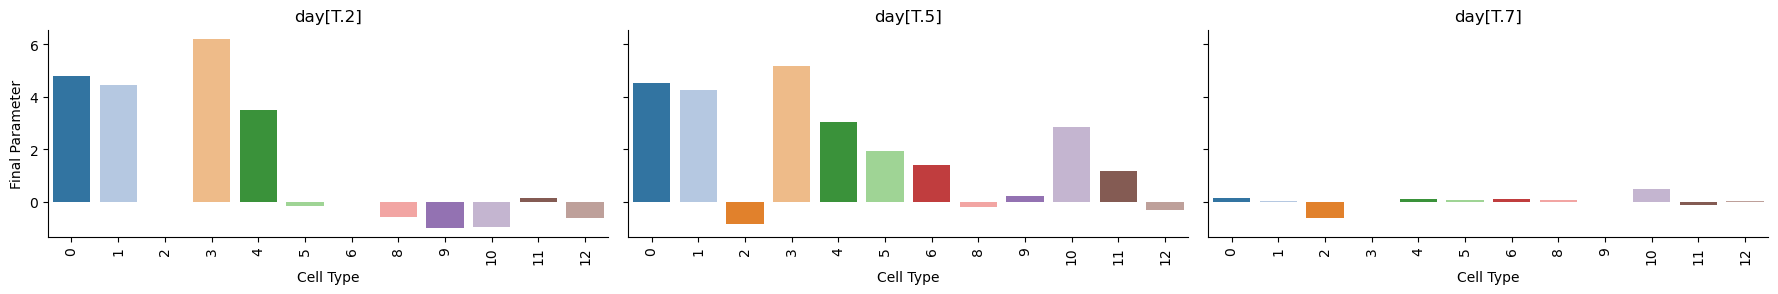

In [14]:
sccoda_model.plot_effects_barplot(sccoda_data, parameter="Final Parameter")